# Sanskrit to English Neural Machine Translation

In [1]:
%pip install torch torchtext nltk bert-score pandas numpy matplotlib tqdm scikit-learn

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 4.9 MB/s eta 0:00:26
    --------------------------------------- 2.1/123.0 MB 6.5 MB/s eta 0:00:19
   - -------------------------------------- 4.2/123.0 MB 7.7 MB/s eta 0:00:16
   - -------------------------------------- 5.2/123.0 MB 6.8 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/123.0 MB 6.7 MB/s eta 0:00:18
   -- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NavinSharma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\NavinSharma\AppData\Roaming\nltk_data...


True

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import time
import random
import math
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from bert_score import score as bert_score
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [5]:
train_sa = pd.read_csv('../Data_to_Students/train_sa_10000.csv')
train_en = pd.read_csv('../Data_to_Students/train_en_10000.csv')
dev_sa = pd.read_csv('../Data_to_Students/dev_sa_1000.csv')
dev_en = pd.read_csv('../Data_to_Students/dev_en_1000.csv')
test_sa = pd.read_csv('../Data_to_Students/test_sa_1000.csv')
test_en = pd.read_csv('../Data_to_Students/test_en_1000.csv')

print(f"Training samples: {len(train_sa)}")
print(f"Dev samples: {len(dev_sa)}")
print(f"Test samples: {len(test_sa)}")
print("\nSample data:")
print(f"Sanskrit: {train_sa['Sentence_sa'].iloc[0]}")
print(f"English: {train_en['Sentence_en'].iloc[0]}")

Training samples: 10000
Dev samples: 1000
Test samples: 1000

Sample data:
Sanskrit: "Ctrl, S नुत्वा रक्षन्तु।"
English: Save it with Ctrl, S.


In [6]:
PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'

class Vocabulary:
    def __init__(self, min_freq=2):
        self.token2idx = {}
        self.idx2token = {}
        self.token_freq = Counter()
        self.min_freq = min_freq

        self.add_token(PAD_TOKEN)
        self.add_token(SOS_TOKEN)
        self.add_token(EOS_TOKEN)
        self.add_token(UNK_TOKEN)

    def add_token(self, token):
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    def build_vocab(self, sentences):
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            self.token_freq.update(tokens)

        for token, freq in self.token_freq.items():
            if freq >= self.min_freq:
                self.add_token(token)

    def tokenize(self, sentence):
        return str(sentence).strip().split()

    def encode(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.token2idx.get(token, self.token2idx[UNK_TOKEN]) for token in tokens]

    def decode(self, indices):
        tokens = [self.idx2token[idx] for idx in indices if idx in self.idx2token]
        return ' '.join(tokens)

    def __len__(self):
        return len(self.token2idx)
print("Building vocabularies...")
src_vocab = Vocabulary(min_freq=2)
tgt_vocab = Vocabulary(min_freq=2)

src_vocab.build_vocab(train_sa['Sentence_sa'].tolist())
tgt_vocab.build_vocab(train_en['Sentence_en'].tolist())

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")

Building vocabularies...
Source vocabulary size: 8485
Target vocabulary size: 7649


In [7]:
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, src_data, tgt_data, src_vocab, tgt_vocab):
        self.src_data = src_data
        self.tgt_data = tgt_data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src_sentence = self.src_data.iloc[idx]['Sentence_sa']
        tgt_sentence = self.tgt_data.iloc[idx]['Sentence_en']

        src_indices = self.src_vocab.encode(src_sentence)
        tgt_indices = [self.tgt_vocab.token2idx[SOS_TOKEN]] + self.tgt_vocab.encode(tgt_sentence) + [self.tgt_vocab.token2idx[EOS_TOKEN]]

        return torch.tensor(src_indices), torch.tensor(tgt_indices)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_lengths = [len(src) for src in src_batch]
    tgt_lengths = [len(tgt) for tgt in tgt_batch]

    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)

    return src_padded, tgt_padded, torch.tensor(src_lengths), torch.tensor(tgt_lengths)

train_dataset = TranslationDataset(train_sa, train_en, src_vocab, tgt_vocab)
dev_dataset = TranslationDataset(dev_sa, dev_en, src_vocab, tgt_vocab)

BATCH_SIZE = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
dev_loader = torch.utils.data.DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Training batches: {len(train_loader)}")
print(f"Dev batches: {len(dev_loader)}")

Training batches: 313
Dev batches: 32


In [8]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn = nn.LSTM(emb_dim, enc_hid_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))

        packed = nn.utils.rnn.pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))

        return outputs, hidden

In [9]:
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, mask):
        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)

        attention = attention.masked_fill(mask == 0, -1e10)

        return torch.softmax(attention, dim=1)

In [10]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn = nn.LSTM((enc_hid_dim * 2) + emb_dim, dec_hid_dim, batch_first=True)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs, mask):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))

        a = self.attention(hidden, encoder_outputs, mask)
        a = a.unsqueeze(1)

        weighted = torch.bmm(a, encoder_outputs)

        rnn_input = torch.cat((embedded, weighted), dim=2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden.unsqueeze(0), cell.unsqueeze(0)))

        hidden = hidden.squeeze(0)
        cell = cell.squeeze(0)
        output = output.squeeze(1)
        embedded = embedded.squeeze(1)
        weighted = weighted.squeeze(1)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))

        return prediction, hidden, cell

In [11]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src, src_lengths):
        batch_size = src.shape[0]
        max_len = src.shape[1]
        mask = torch.arange(max_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)
        mask = mask < src_lengths.unsqueeze(1)
        return mask

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)
        cell = torch.zeros_like(hidden)

        mask = self.create_mask(src, src_lengths)

        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input, hidden, cell, encoder_outputs, mask)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[:, t] if teacher_force else top1

        return outputs

    def beam_search(self, src, src_len, beam_width=3, max_len=50):
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src, src_len)
            cell = torch.zeros_like(hidden)
            mask = self.create_mask(src, src_len)

            sos_idx = tgt_vocab.token2idx[SOS_TOKEN]
            eos_idx = tgt_vocab.token2idx[EOS_TOKEN]

            sequences = [[[sos_idx], 0.0, hidden, cell]]

            for _ in range(max_len):
                all_candidates = []

                for seq, score, h, c in sequences:
                    if seq[-1] == eos_idx:
                        all_candidates.append([seq, score, h, c])
                        continue

                    input = torch.tensor([seq[-1]]).to(self.device)
                    output, new_h, new_c = self.decoder(input, h, c, encoder_outputs, mask)

                    log_probs = torch.log_softmax(output, dim=1)
                    topk_probs, topk_indices = torch.topk(log_probs, beam_width)

                    for i in range(beam_width):
                        candidate = [seq + [topk_indices[0][i].item()],
                                   score + topk_probs[0][i].item(),
                                   new_h,
                                   new_c]
                        all_candidates.append(candidate)

                ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
                sequences = ordered[:beam_width]

                if all(seq[0][-1] == eos_idx for seq in sequences):
                    break

            best_seq = sequences[0][0]
            return best_seq

In [12]:
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)
EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
DROPOUT = 0.5

attn = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc = Encoder(INPUT_DIM, EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
dec = Decoder(OUTPUT_DIM, EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT, attn)

model = Seq2Seq(enc, dec, device).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f'The model has {total_params:,} trainable parameters')

The model has 25,985,249 trainable parameters


In [13]:
PAD_IDX = tgt_vocab.token2idx[PAD_TOKEN]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=0.001)
def train_epoch(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for src, tgt, src_lengths, tgt_lengths in tqdm(iterator, desc='Training'):
        src = src.to(device)
        tgt = tgt.to(device)
        src_lengths = src_lengths.to(device)

        optimizer.zero_grad()

        output = model(src, src_lengths, tgt)

        output_dim = output.shape[-1]
        output = output[:, 1:].contiguous().view(-1, output_dim)
        tgt = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(output, tgt)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt, src_lengths, tgt_lengths in iterator:
            src = src.to(device)
            tgt = tgt.to(device)
            src_lengths = src_lengths.to(device)

            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]
            output = output[:, 1:].contiguous().view(-1, output_dim)
            tgt = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [15]:
N_EPOCHS = 1
CLIP = 1

train_losses = []
dev_losses = []

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    print(f'\nEpoch: {epoch+1}/{N_EPOCHS}')

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, dev_loader, criterion)

    train_losses.append(train_loss)
    dev_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'Model saved with validation loss: {valid_loss:.3f}')

    print(f'Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}')


Epoch: 1/1


Training: 100%|██████████| 313/313 [26:57<00:00,  5.17s/it]


Model saved with validation loss: 5.168
Train Loss: 4.962 | Val Loss: 5.168


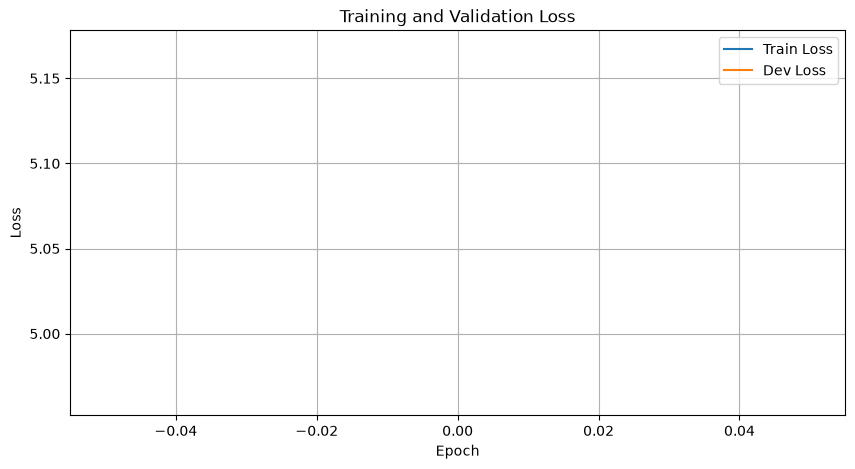

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(dev_losses, label='Dev Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

def translate_sentence(sentence, src_vocab, tgt_vocab, model, device, beam_width=3, max_len=50):
    model.eval()

    src_indices = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)
    src_len = torch.tensor([len(src_indices)]).to(device)

    with torch.no_grad():
        output_indices = model.beam_search(src_tensor, src_len, beam_width=beam_width, max_len=max_len)

    output_tokens = [tgt_vocab.idx2token[idx] for idx in output_indices
                     if idx not in [tgt_vocab.token2idx[SOS_TOKEN],
                                   tgt_vocab.token2idx[EOS_TOKEN],
                                   tgt_vocab.token2idx[PAD_TOKEN]]]

    return ' '.join(output_tokens)

print("Generating predictions for test set")
start_time = time.time()

predictions = []
source_ids = []

for idx in tqdm(range(len(test_sa)), desc='Translating'):
    src_sentence = test_sa['Sentence_sa'].iloc[idx]
    source_id = test_sa['Source_id'].iloc[idx]

    translation = translate_sentence(src_sentence, src_vocab, tgt_vocab, model, device)

    predictions.append(translation)
    source_ids.append(source_id)

inference_time = time.time() - start_time
print(f"\nInference completed in {inference_time:.2f} seconds")
print(f"Total parameters: {total_params:,}")

Generating predictions for test set


Translating: 100%|██████████| 1000/1000 [08:24<00:00,  1.98it/s]


Inference completed in 504.72 seconds
Total parameters: 25,985,249


In [18]:
submission_df = pd.DataFrame({
    'Source_id': source_ids,
    'Sentence_en': predictions
})

submission_df.to_csv('submission.csv', index=False, encoding='utf-8')
print("Submission file saved as 'submission.csv'")

print("\nSample predictions:")
for i in range(min(5, len(submission_df))):
    print(f"Source ID: {submission_df['Source_id'].iloc[i]}")
    print(f"Prediction: {submission_df['Sentence_en'].iloc[i]}")
    print()

Submission file saved as 'submission.csv'

Sample predictions:
Source ID: 1
Prediction: The <unk> is a <unk> <unk> <unk> <unk> <unk> <unk>

Source ID: 2
Prediction: "And I have heard the <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

Source ID: 3
Prediction: "And I have I have to the <unk> I have I have I have to the <unk>

Source ID: 4
Prediction: <unk> the <unk> <unk> the <unk> the <unk> <unk> <unk> the <unk> <unk> the <unk> <unk> <unk> <unk> the <unk> <unk> <unk> the <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> the <unk> <unk> <unk>

Source ID: 5
Prediction: "And the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of <unk>



In [19]:
print("Generating predictions for dev set...")
dev_predictions = []
dev_references = []

for idx in tqdm(range(len(dev_sa)), desc='Translating dev set'):
    src_sentence = dev_sa['Sentence_sa'].iloc[idx]
    ref_sentence = dev_en['Sentence_en'].iloc[idx]

    translation = translate_sentence(src_sentence, src_vocab, tgt_vocab, model, device)

    dev_predictions.append(translation)
    dev_references.append(ref_sentence)

print("\nCalculating BLEU score...")
references_for_bleu = [[ref.split()] for ref in dev_references]
predictions_for_bleu = [pred.split() for pred in dev_predictions]

bleu_score = corpus_bleu(references_for_bleu, predictions_for_bleu)
print(f"BLEU Score (Dev): {bleu_score:.4f}")

print("\nCalculating BERTScore...")
P, R, F1 = bert_score(dev_predictions, dev_references, lang='en', rescale_with_baseline=True, verbose=True)
bertscore_f1 = F1.mean().item()
print(f"BERTScore F1 (Dev): {bertscore_f1:.4f}")

print("\n=== Efficiency Metrics ===")
print(f"Inference Time (Test Set): {inference_time:.2f} seconds")
print(f"Total Model Parameters: {total_params:,}")

Generating predictions for dev set...


Translating dev set: 100%|██████████| 1000/1000 [08:30<00:00,  1.96it/s]



Calculating BLEU score...
BLEU Score (Dev): 0.0234

Calculating BERTScore...


c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NavinSharma\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4151.14it/s]
[transformers] Rober

calculating scores...
computing bert embedding.


100%|██████████| 28/28 [03:52<00:00,  8.29s/it]


computing greedy matching.


100%|██████████| 16/16 [00:00<00:00, 24.07it/s]
c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\bert_score\score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  baselines = torch.from_numpy(


done in 232.81 seconds, 4.30 sentences/sec
BERTScore F1 (Dev): -0.1393

=== Efficiency Metrics ===
Inference Time (Test Set): 504.72 seconds
Total Model Parameters: 25,985,249


In [20]:
print("\n=== Translation Examples ===")
num_examples = min(10, len(dev_sa))

for i in range(num_examples):
    src = dev_sa['Sentence_sa'].iloc[i]
    ref = dev_en['Sentence_en'].iloc[i]
    pred = dev_predictions[i]

    ref_tokens = [ref.split()]
    pred_tokens = pred.split()
    sent_bleu = sentence_bleu(ref_tokens, pred_tokens)

    print(f"\nExample {i+1}:")
    print(f"Source (Sanskrit): {src}")
    print(f"Reference (English): {ref}")
    print(f"Prediction: {pred}")
    print(f"Sentence BLEU: {sent_bleu:.4f}")

    ref_words = set(ref.lower().split())
    pred_words = set(pred.lower().split())
    missing_words = ref_words - pred_words
    extra_words = pred_words - ref_words

    if missing_words:
        print(f"Missing words: {missing_words}")
    if extra_words:
        print(f"Extra words: {extra_words}")
    print("-" * 80)


=== Translation Examples ===

Example 1:
Source (Sanskrit): ते वीराः ।
Reference (English): Those are brave men.
Prediction: Those are two songs.
Sentence BLEU: 0.0000
Missing words: {'men.', 'brave'}
Extra words: {'two', 'songs.'}
--------------------------------------------------------------------------------

Example 2:
Source (Sanskrit): 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
Reference (English): Infinite loop  can cause the system to become unresponsive.
Prediction: <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
Sentence BLEU: 0.0000
Missing words: {'loop', 'system', 'to', 'infinite', 'can', 'become', 'unresponsive.', 'the', 'cause'}
Extra words: {'<unk>'}
--------------------------------------------------------------------------------

Example 3:
Source (Sanskrit): ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
Reference (English): "And they spit upon him, and took the reed, and smote him on the head."
Prediction: "And they were the <unk> of the <u

c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\NavinSharma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gra

In [21]:
print("\n=== Test Set Evaluation ===")

test_references = test_en['Sentence_en'].tolist()

test_references_for_bleu = [[ref.split()] for ref in test_references]
test_predictions_for_bleu = [pred.split() for pred in predictions]

test_bleu_score = corpus_bleu(test_references_for_bleu, test_predictions_for_bleu)
print(f"BLEU Score (Test): {test_bleu_score:.4f}")
print("\nCalculating BERTScore for test set...")
P_test, R_test, F1_test = bert_score(predictions, test_references, lang='en', rescale_with_baseline=True, verbose=True)
test_bertscore_f1 = F1_test.mean().item()
print(f"BERTScore F1 (Test): {test_bertscore_f1:.4f}")

print("\n=== Final Results Summary ===")
print(f"Dev BLEU: {bleu_score:.4f}")
print(f"Dev BERTScore F1: {bertscore_f1:.4f}")
print(f"Test BLEU: {test_bleu_score:.4f}")
print(f"Test BERTScore F1: {test_bertscore_f1:.4f}")
print(f"Inference Time: {inference_time:.2f} seconds")
print(f"Total Parameters: {total_params:,}")


=== Test Set Evaluation ===
BLEU Score (Test): 0.0217

Calculating BERTScore for test set...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3226.91it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 28/28 [04:27<00:00,  9.55s/it]


computing greedy matching.


100%|██████████| 16/16 [00:00<00:00, 29.91it/s]


done in 268.10 seconds, 3.73 sentences/sec
BERTScore F1 (Test): -0.1312

=== Final Results Summary ===
Dev BLEU: 0.0234
Dev BERTScore F1: -0.1393
Test BLEU: 0.0217
Test BERTScore F1: -0.1312
Inference Time: 504.72 seconds
Total Parameters: 25,985,249
